In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")


pd.set_option("display.max_columns", None)

In [2]:
DATA_PATH = "C:\\Users\\vipul\\Desktop\\Fraud_Detection\\data\\raw\\creditcard.csv"

df = pd.read_csv(DATA_PATH)

df = df.drop_duplicates()

print(df.shape)

(283726, 31)


In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
class_counts = df["Class"].value_counts()

print(class_counts)

Class
0    283253
1       473
Name: count, dtype: int64


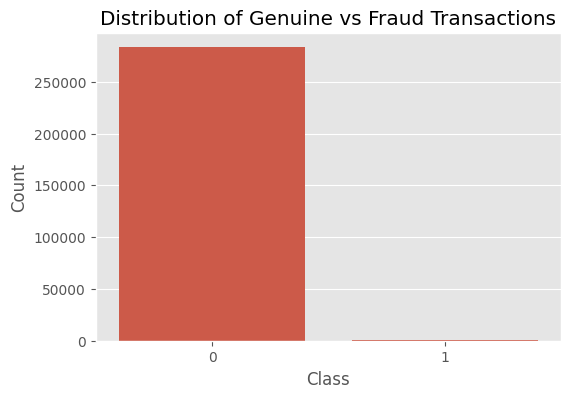

In [5]:
plt.figure(figsize=(6,4))

sns.countplot(x="Class", data=df)

plt.title("Distribution of Genuine vs Fraud Transactions")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [6]:
fraud_percentage = df["Class"].value_counts(normalize=True) * 100

print(fraud_percentage)

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


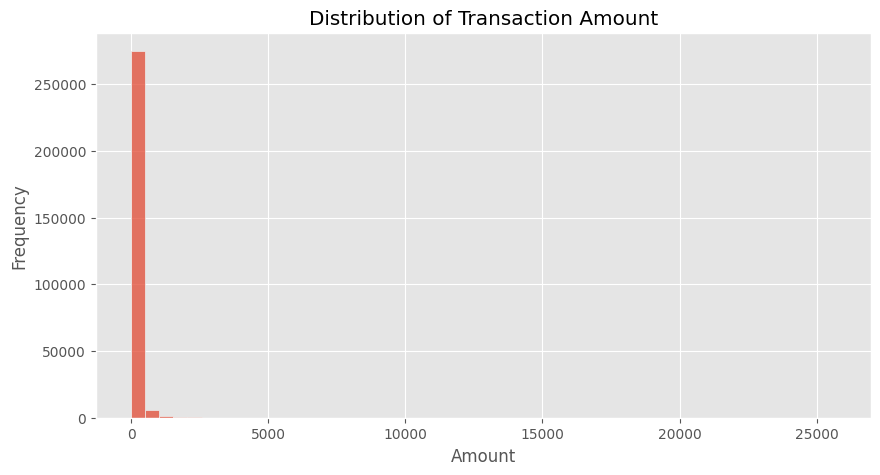

In [7]:
plt.figure(figsize=(10,5))

sns.histplot(df["Amount"], bins=50)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

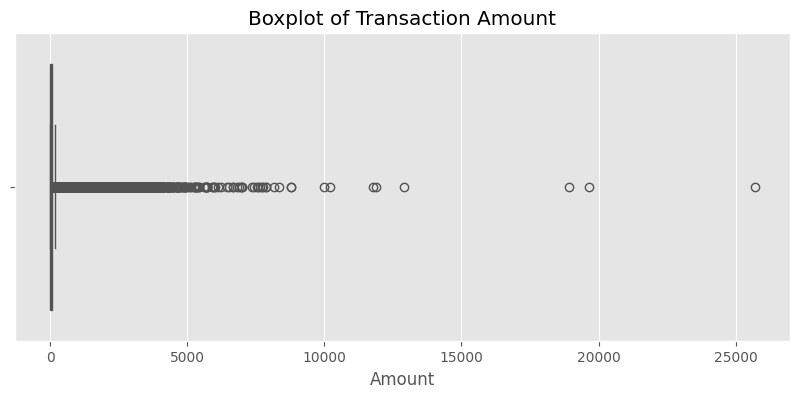

In [8]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df["Amount"])

plt.title("Boxplot of Transaction Amount")

plt.show()

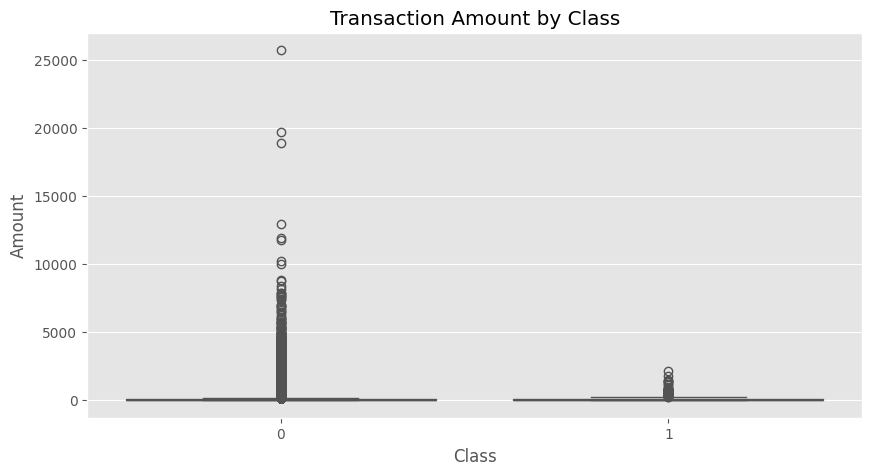

In [9]:
plt.figure(figsize=(10,5))

sns.boxplot(x="Class", y="Amount", data=df)

plt.title("Transaction Amount by Class")

plt.show()

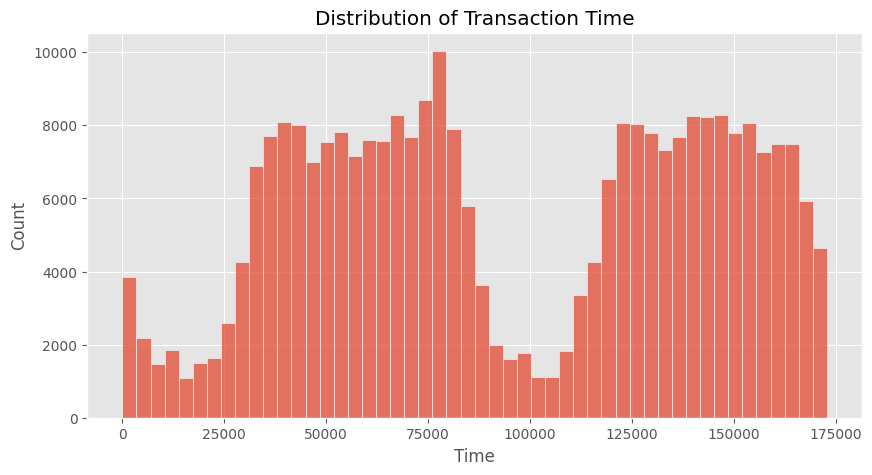

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(df["Time"], bins=50)

plt.title("Distribution of Transaction Time")

plt.xlabel("Time")

plt.show()

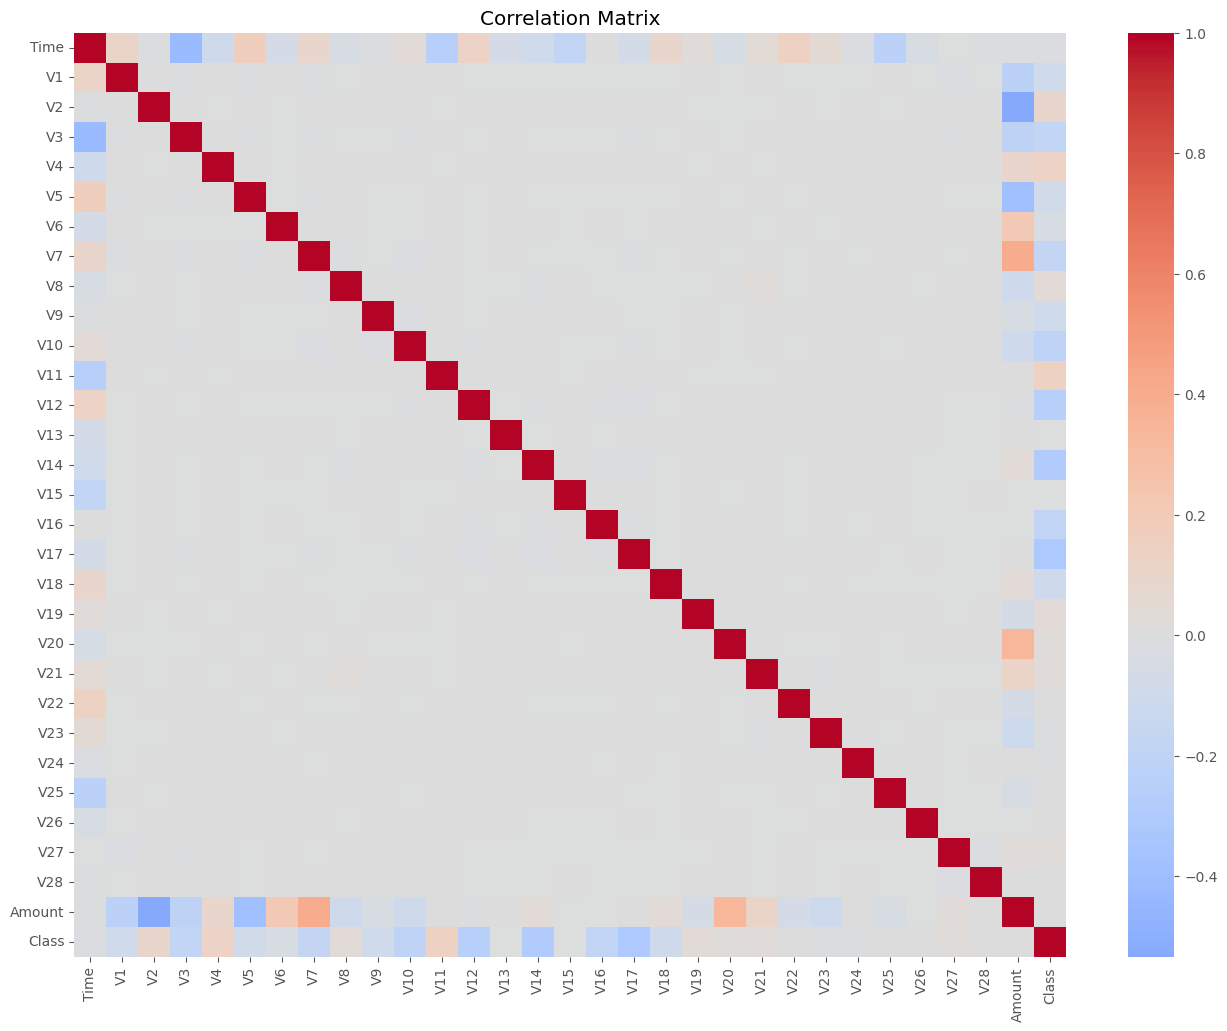

In [11]:
plt.figure(figsize=(16,12))

correlation = df.corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

In [12]:
correlation_with_target = (
    df.corr()["Class"]
      .sort_values(ascending=False)
)

print(correlation_with_target)

Class     1.000000
V11       0.149067
V4        0.129326
V2        0.084624
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
V28       0.009682
Amount    0.005777
V22       0.004887
V26       0.004265
V25       0.003202
V15      -0.003300
V13      -0.003897
V23      -0.006333
V24      -0.007210
Time     -0.012359
V6       -0.043915
V5       -0.087812
V9       -0.094021
V1       -0.094486
V18      -0.105340
V7       -0.172347
V3       -0.182322
V16      -0.187186
V10      -0.206971
V12      -0.250711
V14      -0.293375
V17      -0.313498
Name: Class, dtype: float64


In [14]:
df.to_csv("C:\\Users\\vipul\\Desktop\\Fraud_Detection\\data\\processed\\creditcard_clean.csv", index=False)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.
